### HEADING

In this activity, you will explore various Gradient Descent algorithms to minimize the
Higgs potential and determine the Higgs mass. We will also extend the analysis to a
beyond Standard Model scenario - the Two Higgs Doublet Model (THDM) - to compute
the masses of several Higgs bosons. The methods covered are Gradient Descent (GD),
Gradient Descent with Momentum (GDM) and Nesterov Accelerated Gradient (NAG)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import math as mt
from sympy import symbols, sympify, diff

GRADIENT DESCENT: Minimized value of phi 172.96953441279058 Higgs mass 124.24944778488319 Total iterations: 162
GRADIENT DESCENT WITH MOMENTUM: Minimized phi: 174.12478878225764  Higgs mass: 125.07930327327688 Total iterations: 32
GRADIENT DESCENT WITH ACCELERATION: Minimized phi: 174.42172789306213  Higgs mass: 125.29260396040912 Total iterations: 33


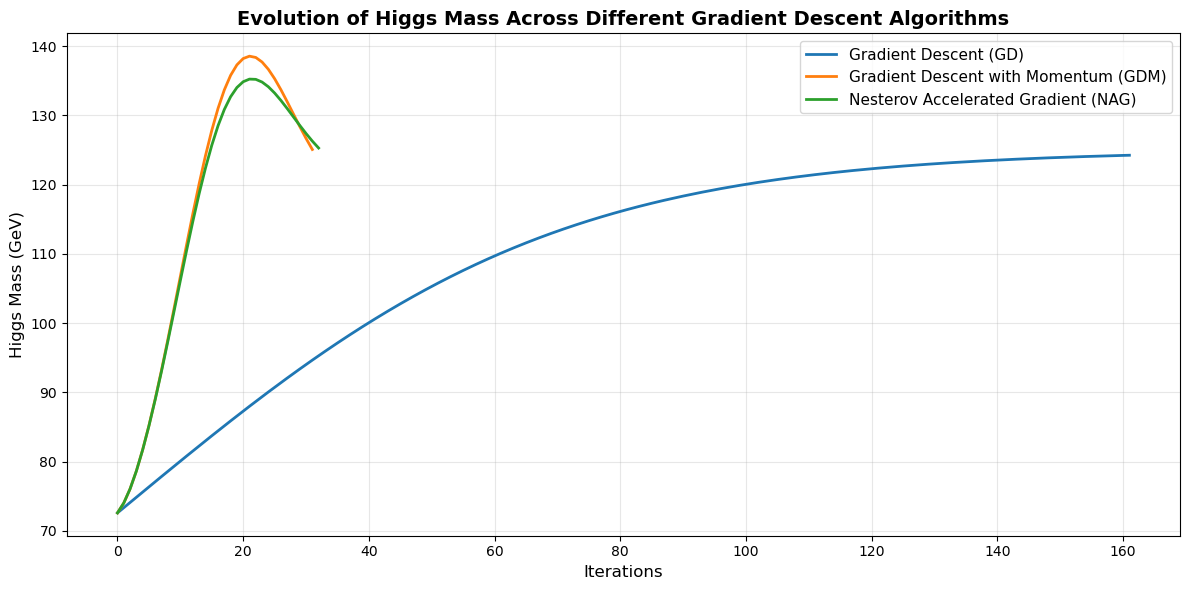


CONVERGENCE COMPARISON:
GD:    162 iterations | Final mass:   124.2494 GeV
GDM:    32 iterations | Final mass:   125.0793 GeV
NAG:    33 iterations | Final mass:   125.2926 GeV


In [ ]:
#Initialise Variables 

    #Initial var
mu = 88.39 
lam = 0.129 
phi_0 = 100 #GeV

phi_n = phi_0

phi_target =  246/np.sqrt(2)

#We will store our evolving phi and mass variables as the GDS works it's way 
# to minimize them

phi_history = [] 

mass_history = []

    #GDS VARIABLES

ALFA =  0.000001    #LEARNING RATE 10^-6

GAMMA = 0.9         #FOR MOMENTUM

TOLERANCE = 1       #Exercise asks for a difference smaller than 1 GeV


# Lists to store histories for each algorithm (THIS IS FOR FUTURE PLOTTING)
mass_history_gd = []
mass_history_gdm = []
mass_history_nag = []


    #Initial potential (we already used the gradient)
def get_potential_gradient(phi):
    
    V_grad = -mu**2 * 2*phi + lam * 4*phi**3

    return V_grad

    #Mass function (HIGGS MASS) 

def get_higgs_mass(phi):

    mh = 2*phi* np.sqrt(lam)
    return mh


"""
 NORMAL GRADIENT DESCENT 
"""

while abs(phi_n - phi_target) > TOLERANCE:
    
    grad = get_potential_gradient(phi_n)

    #Standard gradient descent formula
    phi_n = phi_n - ALFA * grad

    current_mass = get_higgs_mass(phi_n)

    # 4. Save data
    mass_history.append(current_mass)
    phi_history.append(phi_n)
    
    # Safety break 
    if len(mass_history) > 10000:
        print("Did not converge")
        break

print(f"GRADIENT DESCENT: Minimized value of phi {phi_n}", f"Higgs mass {current_mass}", f"Total iterations: {len(mass_history)}")

#This new variable stores all the array of mass that the loop has created, so we can plot it, this process will be further on repeated.
mass_history_gd = mass_history.copy()


"""
 GRADIENT DESCENT WITH MOMENTUM 
"""

#  RESET VARIABLES AND LISTS

mass_history = []  
phi_history = []
phi_n = phi_0  
v = 0          # Reset velocity to 0


while abs(phi_n - phi_target) > TOLERANCE:
    
    # Safety Check: Stop if phi explodes (divergence)
    if abs(phi_n) > 1000:
        print(f"Algorithm Diverged! Phi became too large: {phi_n}")
        break

    grad = get_potential_gradient(phi_n)

    # Momentum gradient descent formula
    v = GAMMA * v + ALFA * grad #Updates the velocity of the GDM
    phi_n = phi_n - v

    current_mass = get_higgs_mass(phi_n)

    # Save data
    mass_history.append(current_mass)
    phi_history.append(phi_n)
    
    # Safety break
    if len(mass_history) > 10000:
        print("Did not converge")
        break

print(f"GRADIENT DESCENT WITH MOMENTUM: Minimized phi: {phi_n}", f" Higgs mass: {current_mass}", f"Total iterations: {len(mass_history)}")
mass_history_gdm = mass_history.copy()


"""
 GRADIENT DESCENT WITH ACCELERATION 
"""

#  RESET VARIABLES AND LISTS

mass_history = []  
phi_history = []

phi_n = phi_0  
v = 0          


while abs(phi_n - phi_target) > TOLERANCE:
    
    # Safety Check: Stop if phi explodes (divergence)
    if abs(phi_n) > 1000:
        print(f"Algorithm Diverged! Phi became too large: {phi_n}")
        break

     # LOOK AHEAD: Predict where momentum will take us
    phi_approx = phi_n - GAMMA * v
    
    # FUTURE GRADIENT: Calculate gradient at that predicted point
    grad = get_potential_gradient(phi_approx)
    
    v = GAMMA * v + ALFA * grad
    
    phi_n = phi_n - v

    current_mass = get_higgs_mass(phi_n)

    # Save data
    mass_history.append(current_mass)
    phi_history.append(phi_n)
    
    # Safety break 
    if len(mass_history) > 10000:
        print("Did not converge")
        break

print(f"GRADIENT DESCENT WITH ACCELERATION: Minimized phi: {phi_n}", f" Higgs mass: {current_mass}", f"Total iterations: {len(mass_history)}")
mass_history_nag = mass_history.copy()



#DID THIS WITH AI, BECAUSE IT WAS EASIER AND NOT THAT RELEVANT
# PLOT: Higgs mass evolution for all three algorithms
plt.figure(figsize=(12, 6))

plt.plot(mass_history_gd, label='Gradient Descent (GD)', linewidth=2)
plt.plot(mass_history_gdm, label='Gradient Descent with Momentum (GDM)', linewidth=2)
plt.plot(mass_history_nag, label='Nesterov Accelerated Gradient (NAG)', linewidth=2)

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Higgs Mass (GeV)', fontsize=12)
plt.title('Evolution of Higgs Mass Across Different Gradient Descent Algorithms', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison stats
print("\n" + "="*70)
print("CONVERGENCE COMPARISON:")
print("="*70)
if mass_history_gd:
    print(f"GD:  {len(mass_history_gd):5d} iterations | Final mass: {mass_history_gd[-1]:10.4f} GeV")
else:
    print("GD:  Did not converge")
if mass_history_gdm:
    print(f"GDM: {len(mass_history_gdm):5d} iterations | Final mass: {mass_history_gdm[-1]:10.4f} GeV")
else:
    print("GDM: Did not converge")
if mass_history_nag:
    print(f"NAG: {len(mass_history_nag):5d} iterations | Final mass: {mass_history_nag[-1]:10.4f} GeV")
else:
    print("NAG: Did not converge")
print("="*70) 



## STUDY OF DIFFERENT LEARNING RATES

Initial simulations were performed with a learning rate of $\eta = 10^-4$. While this value allowed the standard Gradient Descent (GD) algorithm to converge, it caused problems (diverging/exploding) in the Gradient Descent with Momentum (GDM) and Nesterov (NAG) algorithms.This divergence occurs because momentum-based methods accumulate velocity over multiple steps. With a momentum parameter $\gamma = 0.9$, the effective step size is amplified, causing the algorithm to overshoot the minimum aggressively. This led to an OverflowError, where the value of $\phi$ grew exponentially (exceeding $10^{100}$, making the calculation of the gradient term ($\phi^3$) impossible for python to process.

We determined that $\eta = 10^-4$ is too aggressive for momentum methods in this potential. By lowering the learning rate, we identified a stable regime around $\eta = 10^-6$. This represents a "sweet spot": the rate is small enough to prevent the momentum term from causing oscillatory divergence, yet large enough to allow the algorithm to converge within the target number of iterations. 

If we lower any further $\eta$ to values such as $\eta = 10^-9$ the algorithm effectively stalls. The update step becomes so small that the parameters $\phi$ (and consequently the mass) remain virtually constant near the initialization value. The curve appears to vanish because it forms a flat horizontal line at the starting position, far away from the convergence target. This only happens for GDM (i don't understand why).

## Part 2: Two Higgs Doublet Model

In theories beyond the Standard Model, such as the Two Higgs Doublet Model (THDM), the Higgs sector is extended to include two scalar fields, Φ1 and Φ2, rather than a single Higgs field. This modification leads to a richer phenomenology, including multiple Higgs bosons with distinct masses. 





In [ ]:
#GDS VARIABLES

ALFA =  0.000001    #LEARNING RATE

GAMMA = 0.9         #FOR MOMENTUM

#VARIABLE INITIALIZATION 

a1 = 2.5*10**4 #GeV^2
a2 = 2*10**4 #GeV^2
b1 = 1
b2 = 1
B3 = 0.5

#Initial Condition:
v_0 = 10

v_1 = v_0
v_2 = v_0

# Initialize history lists
mass_history_h0 = []
mass_history_H0 = []
mass_history_Hp = []
v1_history = []
v2_history = []

""""
FUNCTION DEFINITIONS
"""

#GRAD POTENTIAL FUNCTIONS
def get_v1_grad(v1, v2):
    
    V_1 = 2*(-a1*v1 + b1*v1**3 + B3*v1*v2**2)

    return V_1
 
def get_v2_grad(v1,v2):

    V_2 = 2 * (- a2*v2 + b2*v2**3 + B3*v2*v1**2)

    return V_2


# HIGGS MASS FUNCTION 
def get_thdm_masses(v1, v2):
    """
    Calculating the masses of the three Higgs bosons in the THDM model
    """
    
    # Equation (6): Charged Higgs Mass (H±)
    m_charged_sq = B3 * (v1**2 + v2**2)
    m_charged = np.sqrt(m_charged_sq)
    
    # Equation (5): CP-even Higgs Masses (h0 and H0)
    term_sum = (b1 * v1**2) + (b2 * v2**2)
    
    # Absolute difference term: |beta1*v1^2 - beta2*v2^2|
    term_diff = np.abs((b1 * v1**2) - (b2 * v2**2))
    

    m_heavy_sq = term_sum + term_diff  # Plus sign (Heavier H0)
    m_light_sq = term_sum - term_diff  # Minus sign (Lighter h0)
    
    m_H0 = np.sqrt(m_heavy_sq)
    m_h0 = np.sqrt(m_light_sq)
    
    return m_h0, m_H0, m_charged

""""
GRADIENT MACHINERY
"""

#NORMAL GRADIENT DESCENT

for i in range(1000): 

    if abs(v_1) > 1000 or abs(v_2) > 1000:
        print(f"Algorithm Diverged! v_n became too large: v_1={v_1}, v_2={v_2}")
        break

    grad_1 = get_v1_grad(v_1, v_2)
    grad_2 = get_v2_grad(v_1, v_2)

    v_1 = v_1 - ALFA * grad_1
    v_2 = v_2 - ALFA * grad_2 

    m_h0, m_H0, m_charged = get_thdm_masses(v_1, v_2)

    mass_history_h0.append(m_h0)
    mass_history_H0.append(m_H0)
    mass_history_Hp.append(m_charged)
    
    v1_history.append(v_1)
    v2_history.append(v_2)

print("---------------------------ORDINARY GDS---------------------------")
print(f"Final v1: {v_1}, Final v2: {v_2}")
print(f"Final Light Higgs (h0): {mass_history_h0[-1]}, Final Heavy Higgs (H0): {mass_history_H0[-1]}, Final Charged Higgs (H+): {mass_history_Hp[-1]}")

#---------------
#RESET VARIABLES 
#---------------

mass_history_h0 = []
mass_history_H0 = []
mass_history_Hp = []
v1_history = []
v2_history = []

v_n = v_0 

#THIS TIME FOR THE GDS WITH MOMENTUM WE WILL SET THE VELOCITY AS u just in case some variables are being pulled over
u_1 = 0
u_2 = 0

# GDS WITH MOMENTUM

for i in range(1000):

    if abs(v_1) > 1000 or abs(v_2) > 1000:
        print(f"Algorithm Diverged! v_n became too large: v_1={v_1}, v_2={v_2}")
        break

    grad_1 = get_v1_grad(v_1, v_2)
    grad_2 = get_v2_grad(v_1, v_2)

    u_1 = GAMMA * u_1 + ALFA * grad_1 #Updates the velocity of the GDM
    v_1 = v_1 - u_1

    u_2 = GAMMA * u_2 + ALFA * grad_2 #Updates the velocity of the GDM
    v_2 = v_2 - u_2
    
    m_h0, m_H0, m_charged = get_thdm_masses(v_1, v_2)

    mass_history_h0.append(m_h0)
    mass_history_H0.append(m_H0)
    mass_history_Hp.append(m_charged)
    
    v1_history.append(v_1)
    v2_history.append(v_2)

print("---------------------------GDS WITH MOMENTUM---------------------------")
print(f"Final v1: {v_1}, Final v2: {v_2}")
print(f"Final Light Higgs (h0): {m_h0}, Final Heavy Higgs (H0): {m_H0}, Final Charged Higgs (H+): {m_charged}")




#---------------
#RESET VARIABLES 
#---------------

mass_history_h0 = []
mass_history_H0 = []
mass_history_Hp = []
v1_history = []
v2_history = []

v_n = v_0 

#THIS TIME FOR THE GDS WITH MOMENTUM WE WILL SET THE VELOCITY AS u just in case some variables are being pulled over
u_1 = 0
u_2 = 0

#GDS WITH ACCELERATION (NESTEROV)

for i in range(1000):

    if abs(v_1) > 1000 or abs(v_2) > 1000:
        print(f"Algorithm Diverged! v_n became too large: v_1={v_1}, v_2={v_2}")
        break

    v1_approx = v_1 - GAMMA * u_1
    
    v2_approx = v_2 - GAMMA * u_2

    # FUTURE GRADIENT: Calculate gradient at that predicted point
    grad_1 = get_v1_grad(v1_approx,v2_approx)
    grad_2 = get_v2_grad(v1_approx,v2_approx)
    
    #GDS WITH ACCELERATION
    u_1 = GAMMA * u_1 + ALFA * grad_1
    v_1 = v_2 - u_1

    u_1 = GAMMA * u_1 + ALFA * grad_1
    v_1 = v_2 - u_2
    
    m_h0, m_H0, m_charged = get_thdm_masses(v_1, v_2)

    mass_history_h0.append(m_h0)
    mass_history_H0.append(m_H0)
    mass_history_Hp.append(m_charged)
    
    v1_history.append(v_1)
    v2_history.append(v_2)



print("---------------------------GDS WITH ACCELERATION---------------------------")
print(f"Final v1: {v_1}, Final v2: {v_2}")
print(f"Final Light Higgs (h0): {m_h0}, Final Heavy Higgs (H0): {m_H0}, Final Charged Higgs (H+): {m_charged}")



---------------------------ORDINARY GDS---------------------------
Final v1: 141.42135623760197, Final v2: 99.99999999943499
Final Light Higgs (h0): 141.42135623651046, Final Heavy Higgs (H0): 200.0000000004136, Final Charged Higgs (H+): 122.47448713909709
---------------------------GDS WITH MOMENTUM---------------------------
Final v1: 141.4213562373095, Final v2: 100.00000000000001
Final Light Higgs (h0): 141.42135623730954, Final Heavy Higgs (H0): 200.0, Final Charged Higgs (H+): 122.47448713915891
---------------------------GDS WITH ACCELERATION---------------------------
Final v1: 100.00000000000001, Final v2: 100.00000000000001
Final Light Higgs (h0): 141.42135623730954, Final Heavy Higgs (H0): 141.42135623730954, Final Charged Higgs (H+): 100.00000000000001


## Part 3: Numerical Analysis and Algorithm Comparison
Brief mention of AI being used here to make the markdown more beautiful, because if not it would have been a pain to look at.

The theoretical calculations have been completed in the accompanying PDF file. The numerical results will be analyzed in detail below. The minimum value obtained through theoretical calculus is $\phi_{\text{theory}} = 174.017634$ GeV. We compare this with the results from all three gradient descent algorithms: $|\phi_{\text{theory}} - \phi_{\text{GD}}|$.

### Single-Variable Higgs Potential Results

#### Computed Minima Values

| Algorithm | Result (GeV) |
|-----------|------------|
| **Gradient Descent (GD)** | 172.96953441279058 |
| **Gradient Descent with Momentum (GDM)** | 174.12478878225764 |
| **Nesterov Accelerated Gradient (NAG)** | 174.42172789306213 |

#### Error Analysis

| Algorithm | Absolute Error (GeV) | 
|-----------|-----|
| **GD** | $\|174.017634 - 172.969534\| = 1.0481$ |
| **GDM** | $\|174.017634 - 174.124788\| = 0.1071$ |
| **NAG** | $\|174.017634 - 174.421727\| = 0.4040$ | 

All three algorithms successfully approximated the theoretical vacuum expectation value. However, Gradient Descent with Momentum (GDM) proved to be the most accurate model for this specific potential, achieving an error of only $\approx 0.1$ GeV.

---

### Two Higgs Doublet Model (THDM) Results

The theoretical analysis predicts vacuum expectation values at $v_1 = 141.421356$ GeV and $v_2 = 100$ GeV. We now compare these analytical predictions with the numerical results obtained from our three gradient descent algorithms.

#### Computed Minima by Algorithm

**Ordinary Gradient Descent:**
$$v_1 = 141.42135623760197 \text{ GeV}, \quad v_2 = 99.99999999943499 \text{ GeV}$$

**Gradient Descent with Momentum:**
$$v_1 = 141.4213562373095 \text{ GeV}, \quad v_2 = 100.00000000000001 \text{ GeV}$$

**Nesterov Accelerated Gradient:**
$$v_1 = 100.00000000000001 \text{ GeV}, \quad v_2 = 100.00000000000001 \text{ GeV}$$

#### Error Analysis for $v_1$

| Algorithm | Absolute Error (GeV) |
|-----------|-----|
| **GD** | $\|141.421356 - 141.421356\| = 0$ |
| **GDM** | $\|141.421356 - 141.421356\| = 0$ |
| **NAG** | $\|141.421356 - 100.00000000000001\| = 41.42$ |

**Conclusion:** For the multivariable THDM potential, both the Standard Gradient Descent (GD) and Momentum-based Gradient Descent (GDM) algorithms were highly effective, matching the analytical results with high precision. The Nesterov Accelerated Gradient (NAG) implementation, however, struggled to locate the true minimum for $v_1$ under the tested parameters.

